# Part 4 — Gradient Descent in Code
Converts the Part 3 manual calculations (4 iterations, one per group member) into working Python.
Each section below mirrors a step from the handwritten work so it can be shown side-by-side live.

## Setup
Same data, starting `m`, `b`, and learning rate as Part 3.

In [ ]:
import numpy as np
from scipy.optimize import approx_fprime
import matplotlib.pyplot as plt


X = np.array([[1, 3],
              [4, 10]], dtype=float)
y = np.array([5, 6], dtype=float)

m = np.array([-1.0, 2.0])   # initial m
b = np.array([1.0, 1.0])    # initial b

alpha = 0.01                
n_iterations = 4              # team of 4, one update per member


## Functions
`predict` does the matrix multiplication for ŷ.

`cost_function` is the MSE equation.

`compute_gradient_scipy` is the part the assignment specifically asks for: **a function, built with SciPy, that accepts an equation and computes its derivative.** It uses `scipy.optimize.approx_fprime` to numerically differentiate `cost_function` with respect to every entry of `m` and `b`.

In [2]:
def predict(m, b, X):
    """y_hat = X @ m + b, matrix form (no scalar treatment)."""
    return X @ m + b


def cost_function(params, X, y):
    """
    The 'equation' referred to in the assignment: Mean Squared Error.
    params packs m and b into one vector so SciPy can differentiate
    with respect to all four numbers at once.
    """
    m = params[:2]
    b = params[2:]
    y_hat = X @ m + b
    error = y_hat - y
    return np.mean(error ** 2)


def compute_gradient_scipy(m, b, X, y, epsilon=1e-6):
    """
    Required by Part 4: 'Using SciPy, implement a function that accepts
    an equation and computes its derivative.'
    approx_fprime numerically differentiates cost_function w.r.t. every
    entry of params (i.e. w.r.t. m and b).
    """
    params = np.concatenate([m, b])
    grad = approx_fprime(params, cost_function, epsilon, X, y)
    return grad[:2], grad[2:]   # grad_m, grad_b


## Initial state (Iteration 0)

In [3]:
history_m, history_b, history_error = [], [], []

y_hat = predict(m, b, X)
error = y_hat - y
mse = np.mean(error ** 2)
print(f"m = {m}")
print(f"b = {b}")
print(f"y_hat = {y_hat}")
print(f"error (y_hat - y) = {error}")
print(f"MSE = {mse:.4f}")

history_m.append(m.copy())
history_b.append(b.copy())
history_error.append(mse)


m = [-1.  2.]
b = [1. 1.]
y_hat = [ 6. 17.]
error (y_hat - y) = [ 1. 11.]
MSE = 61.0000


## Iterative updates
Each loop pass: SciPy computes the derivative, the analytic gradient is shown for comparison (these should match), then `m` and `b` are updated explicitly in matrix form — nothing hidden inside a single black-box call.

In [ ]:
for i in range(1, n_iterations + 1):
    print(f"ITERATION {i}")

    
    grad_m_scipy, grad_b_scipy = compute_gradient_scipy(m, b, X, y)
    print(f"SciPy gradient wrt m : {grad_m_scipy}")
    print(f"SciPy gradient wrt b : {grad_b_scipy}")

   
    y_hat = predict(m, b, X)
    error = y_hat - y
    n = len(y)
    grad_m = (2 / n) * (X.T @ error)
    grad_b = (2 / n) * error
    print(f"Analytic gradient wrt m: {grad_m}  (should match SciPy line above)")
    print(f"Analytic gradient wrt b: {grad_b}  (should match SciPy line above)")
    m = m - alpha * grad_m
    b = b - alpha * grad_b

    y_hat = predict(m, b, X)
    error = y_hat - y
    mse = np.mean(error ** 2)

    print(f"Updated m = {m}")
    print(f"Updated b = {b}")
    print(f"New y_hat = {y_hat}")
    print(f"New error = {error}")
    print(f"New MSE   = {mse:.4f}")
    print()

    history_m.append(m.copy())
    history_b.append(b.copy())
    history_error.append(mse)


ITERATION 1
SciPy gradient wrt m : [ 45.0000085  113.00005452]
SciPy gradient wrt b : [ 1.0000005  11.00000051]
Analytic gradient wrt m: [ 45. 113.]  (should match SciPy line above)
Analytic gradient wrt b: [ 1. 11.]  (should match SciPy line above)
Updated m = [-1.45  0.87]
Updated b = [0.99 0.89]
New y_hat = [2.15 3.79]
New error = [-2.85 -2.21]
New MSE   = 6.5033

ITERATION 2
SciPy gradient wrt m : [-11.6899915 -30.6499455]
SciPy gradient wrt b : [-2.8499995 -2.2099995]
Analytic gradient wrt m: [-11.69 -30.65]  (should match SciPy line above)
Analytic gradient wrt b: [-2.85 -2.21]  (should match SciPy line above)
Updated m = [-1.3331  1.1765]
Updated b = [1.0185 0.9121]
New y_hat = [3.2149 7.3447]
New error = [-1.7851  1.3447]
New MSE   = 2.4974

ITERATION 3
SciPy gradient wrt m : [3.5937085 8.0917545]
SciPy gradient wrt b : [-1.7850995  1.3447005]
Analytic gradient wrt m: [3.5937 8.0917]  (should match SciPy line above)
Analytic gradient wrt b: [-1.7851  1.3447]  (should match SciP

## Final result
This is what to say for *'compute predictions using the final values of m and b'*.

In [5]:
print(f"Final m = {m}")
print(f"Final b = {b}")
print(f"Final predictions y_hat = {predict(m, b, X)}")
print(f"Target y                = {y}")


Final m = [-1.36371103  1.11912761]
Final b = [1.05681037 0.89486965]
Final predictions y_hat = [3.05048217 6.63130163]
Target y                = [5. 6.]


## Plot 1 — how m and b change over iterations

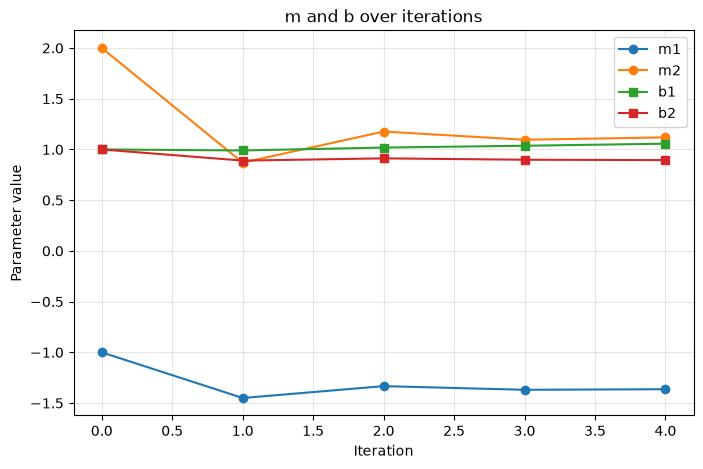

In [6]:
history_m = np.array(history_m)
history_b = np.array(history_b)

fig1, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(history_m[:, 0], marker='o', label='m1')
ax1.plot(history_m[:, 1], marker='o', label='m2')
ax1.plot(history_b[:, 0], marker='s', label='b1')
ax1.plot(history_b[:, 1], marker='s', label='b2')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Parameter value')
ax1.set_title('m and b over iterations')
ax1.legend()
ax1.grid(True, alpha=0.3)
plt.show()


## Plot 2 — how the error (MSE) changes over iterations

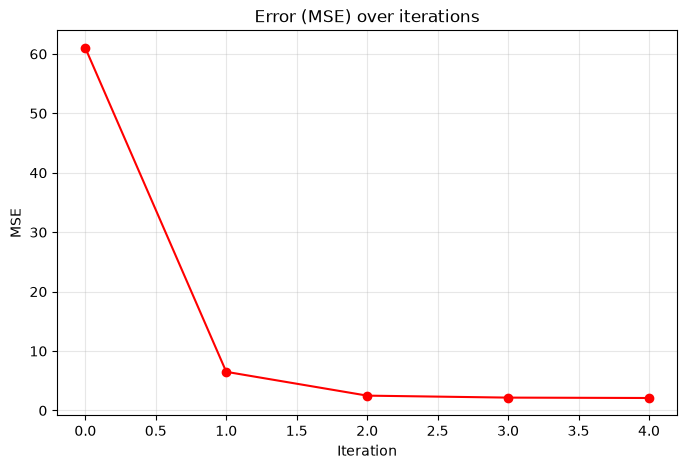

In [7]:
fig2, ax2 = plt.subplots(figsize=(8, 5))
ax2.plot(history_error, marker='o', color='red')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('MSE')
ax2.set_title('Error (MSE) over iterations')
ax2.grid(True, alpha=0.3)
plt.show()


## Trend discussion
MSE drops sharply after iteration 1 (61 → ~6.5) then keeps decreasing but flattens (→ ~2.5 → ~2.16 → ~2.1). Both `m` and `b` are moving in the direction that reduces error, confirming gradient descent is working — it's just slowing down as it approaches a minimum, which is expected with a fixed learning rate.